In [2]:
import os
import warnings

import numpy as np
from scipy.stats import norm as normal

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import anndata as ad
import scanpy as sc
import palantir
import mellon

## covid_dm

In [10]:
covid_ad = sc.read_h5ad("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/real/covid19-pbmc/covid.h5ad")

In [11]:
covid_ad

AnnData object with n_obs × n_vars = 44721 × 26361
    obs: 'orig.ident', 'nCount_SCT', 'nFeature_SCT', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.rps', 'percent.rpl', 'percent.rrna', 'SCT_snn_res.1', 'seurat_clusters', 'singler', 'Admission.level', 'cell.type.fine', 'cell.type.coarse', 'cell.type', 'IFN1', 'HLA1', 'Donor.orig', 'Donor.full', 'Donor', 'Status', 'Sex', 'DPS', 'DTF', 'Admission', 'Ventilated', 'ident'
    var: 'features', 'SCT_features'
    obsm: 'X_pca'
    layers: 'SCT'

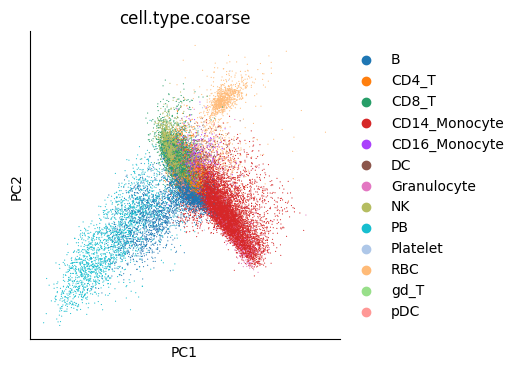

In [12]:
sc.pl.embedding(covid_ad,"pca",color = "cell.type.coarse")

In [13]:
covid_ad.X.todense()

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]])

In [14]:
dm_res = palantir.utils.run_diffusion_maps(covid_ad, n_components=30)

In [15]:
covid_ad.obsm["DM_EigenVectors"].shape

(44721, 30)

In [16]:
covid_ad.obsm["X_pca"].shape

(44721, 50)

In [17]:
covid_ad.obsm["X_pca"] = covid_ad.obsm["DM_EigenVectors"]

In [18]:
covid_ad.obsm["X_pca"].shape

(44721, 30)

In [19]:
covid_ad.write("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/real/covid19-pbmc/covid_dm.h5ad")

In [23]:
import pandas as pd

In [26]:
umap = pd.read_csv("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/not_use/extra_data/covid_umap.txt",sep = "\t")

In [32]:
umap.values.T

array([[ 6.22838870e+00,  2.45706357e+00,  3.62718867e+00, ...,
         6.67652843e+00,  8.44808268e+00,  1.04568892e-02],
       [ 7.01178047e+00,  9.29456607e+00,  1.12693135e+01, ...,
        -5.22041551e+00, -5.66882544e+00,  9.53583159e+00]])

In [34]:
covid_ad.obsm["X_umap"] = umap.values

In [35]:
covid_ad

AnnData object with n_obs × n_vars = 44721 × 26361
    obs: 'orig.ident', 'nCount_SCT', 'nFeature_SCT', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.rps', 'percent.rpl', 'percent.rrna', 'SCT_snn_res.1', 'seurat_clusters', 'singler', 'Admission.level', 'cell.type.fine', 'cell.type.coarse', 'cell.type', 'IFN1', 'HLA1', 'Donor.orig', 'Donor.full', 'Donor', 'Status', 'Sex', 'DPS', 'DTF', 'Admission', 'Ventilated', 'ident'
    var: 'features', 'SCT_features'
    uns: 'cell.type.coarse_colors', 'DM_EigenValues'
    obsm: 'X_pca', 'DM_EigenVectors', 'X_umap'
    layers: 'SCT'
    obsp: 'DM_Kernel', 'DM_Similarity'

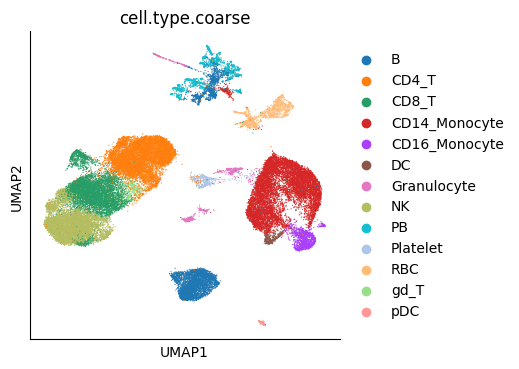

In [36]:
sc.pl.embedding(covid_ad,"umap",color = "cell.type.coarse")

In [71]:
covid_ad

AnnData object with n_obs × n_vars = 44721 × 26361
    obs: 'orig.ident', 'nCount_SCT', 'nFeature_SCT', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.rps', 'percent.rpl', 'percent.rrna', 'SCT_snn_res.1', 'seurat_clusters', 'singler', 'Admission.level', 'cell.type.fine', 'cell.type.coarse', 'cell.type', 'IFN1', 'HLA1', 'Donor.orig', 'Donor.full', 'Donor', 'Status', 'Sex', 'DPS', 'DTF', 'Admission', 'Ventilated', 'ident'
    var: 'features', 'SCT_features'
    uns: 'cell.type.coarse_colors', 'DM_EigenValues'
    obsm: 'X_pca', 'DM_EigenVectors', 'X_umap'
    layers: 'SCT'
    obsp: 'DM_Kernel', 'DM_Similarity'

In [48]:
metadata_example = pd.read_csv("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/real/covid19-pbmc/covid19-pbmc-B-0.95-45-0-No-mellon_pca-DM/iteration_0/benchmark_covid19-pbmc_pop_B_enr0.95_seed45.coldata.csv",index_col = 0)

/loc/scratch/9227958/ipykernel_322/4100277272.py:1: DtypeWarning: Columns (13,19,26) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_example = pd.read_csv("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/real/covid19-pbmc/covid19-pbmc-B-0.95-45-0-No-mellon_pca-DM/iteration_0/benchmark_covid19-pbmc_pop_B_enr0.95_seed45.coldata.csv",index_col = 0)


In [76]:
metadata_example_pca = pd.read_csv("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/real/covid19-pbmc/covid19-pbmc-B-0.95-45-0-No-mellon_pca/iteration_0/benchmark_covid19-pbmc_pop_B_enr0.95_seed45.coldata.csv",index_col = 0)

/loc/scratch/9227958/ipykernel_322/3158947901.py:1: DtypeWarning: Columns (13,19,26) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_example_pca = pd.read_csv("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/real/covid19-pbmc/covid19-pbmc-B-0.95-45-0-No-mellon_pca/iteration_0/benchmark_covid19-pbmc_pop_B_enr0.95_seed45.coldata.csv",index_col = 0)


In [77]:
metadata_example_pca

,orig.ident,nCount_SCT,nFeature_SCT,nCount_RNA,nFeature_RNA,percent.mt,percent.rps,percent.rpl,percent.rrna,SCT_snn_res.1,...,DTF,Admission,Ventilated,ident,synth_labels,Condition1_prob,Condition2_prob,synth_samples,synth_batches,true_labels
rowname,,,,,,,,,,,,,,,,,,,,,
covid_555_1.1,0,1682.0,126,1222.0,125,1.309329,0.081833,0.245499,46.644845,12,...,9.0,ICU,NonVent,12,Condition2,0.534074,0.465926,Condition2_R1,B1,NotDA
covid_555_1.2,0,1700.0,160,1099.0,160,13.102821,0.363967,0.363967,58.780710,9,...,9.0,ICU,NonVent,9,Condition1,0.659581,0.340419,Condition1_R2,B1,NegLFC
covid_555_1.3,0,1661.0,213,1055.0,212,2.938389,0.663507,0.947867,55.829384,18,...,9.0,ICU,NonVent,18,Condition1,0.583318,0.416682,Condition1_R3,B2,NotDA
covid_555_1.7,0,1971.0,312,2411.0,312,10.908337,0.041477,0.165906,67.399419,9,...,9.0,ICU,NonVent,9,Condition1,0.584742,0.415258,Condition1_R1,B1,NotDA
covid_555_1.8,0,1948.0,336,2276.0,336,11.203866,0.263620,0.307557,67.355009,21,...,9.0,ICU,NonVent,21,Condition1,0.600787,0.399213,Condition1_R2,B1,NotDA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HIP045.2543,13,1959.0,1080,6103.0,2460,6.898247,2.867442,3.637555,10.797968,6,...,0.0,NaN,Healthy,6,Condition2,0.583549,0.416451,Condition2_R2,B2,NotDA
HIP045.2544,13,2088.0,1031,7324.0,2488,6.485527,4.929001,6.157837,12.738940,20,...,0.0,NaN,Healthy,20,Condition1,0.571561,0.428439,Condition1_R3,B2,NotDA
HIP045.2545,13,1929.0,1021,6368.0,2511,4.742462,4.978015,6.171482,14.400126,20,...,0.0,NaN,Healthy,20,Condition1,0.582031,0.417969,Condition1_R1,B1,NotDA


In [49]:
metadata_example

,orig.ident,nCount_SCT,nFeature_SCT,nCount_RNA,nFeature_RNA,percent.mt,percent.rps,percent.rpl,percent.rrna,SCT_snn_res.1,...,DTF,Admission,Ventilated,ident,synth_labels,Condition1_prob,Condition2_prob,synth_samples,synth_batches,true_labels
rowname,,,,,,,,,,,,,,,,,,,,,
covid_555_1.1,0,1682.0,126,1222.0,125,1.309329,0.081833,0.245499,46.644845,12,...,9.0,ICU,NonVent,12,Condition2,0.569627,0.430373,Condition2_R1,B1,NotDA
covid_555_1.2,0,1700.0,160,1099.0,160,13.102821,0.363967,0.363967,58.780710,9,...,9.0,ICU,NonVent,9,Condition1,0.597270,0.402730,Condition1_R2,B1,NotDA
covid_555_1.3,0,1661.0,213,1055.0,212,2.938389,0.663507,0.947867,55.829384,18,...,9.0,ICU,NonVent,18,Condition1,0.576182,0.423818,Condition1_R3,B2,NotDA
covid_555_1.7,0,1971.0,312,2411.0,312,10.908337,0.041477,0.165906,67.399419,9,...,9.0,ICU,NonVent,9,Condition1,0.613564,0.386436,Condition1_R1,B1,NegLFC
covid_555_1.8,0,1948.0,336,2276.0,336,11.203866,0.263620,0.307557,67.355009,21,...,9.0,ICU,NonVent,21,Condition1,0.620114,0.379886,Condition1_R2,B1,NegLFC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HIP045.2543,13,1959.0,1080,6103.0,2460,6.898247,2.867442,3.637555,10.797968,6,...,0.0,NaN,Healthy,6,Condition2,0.598122,0.401878,Condition2_R2,B2,NotDA
HIP045.2544,13,2088.0,1031,7324.0,2488,6.485527,4.929001,6.157837,12.738940,20,...,0.0,NaN,Healthy,20,Condition1,0.556998,0.443002,Condition1_R3,B2,NotDA
HIP045.2545,13,1929.0,1021,6368.0,2511,4.742462,4.978015,6.171482,14.400126,20,...,0.0,NaN,Healthy,20,Condition1,0.541107,0.458893,Condition1_R1,B1,NotDA


In [74]:
covid_ad_test.obs["true_lfc"] = np.log(metadata_example["Condition2_prob"]) - np.log(metadata_example["Condition1_prob"])

In [50]:
covid_ad_test = covid_ad.copy()

In [78]:
covid_ad.obs["true_lfc_pca"] = np.log(metadata_example_pca["Condition2_prob"]) - np.log(metadata_example_pca["Condition1_prob"])

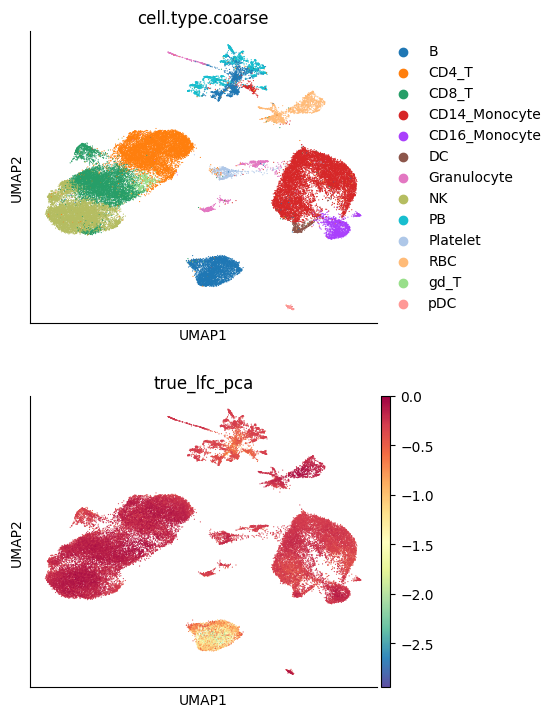

In [80]:
sc.pl.embedding(covid_ad,"umap",color = ["cell.type.coarse","true_lfc_pca"],ncols = 1)

In [51]:
covid_ad_test.obs = metadata_example

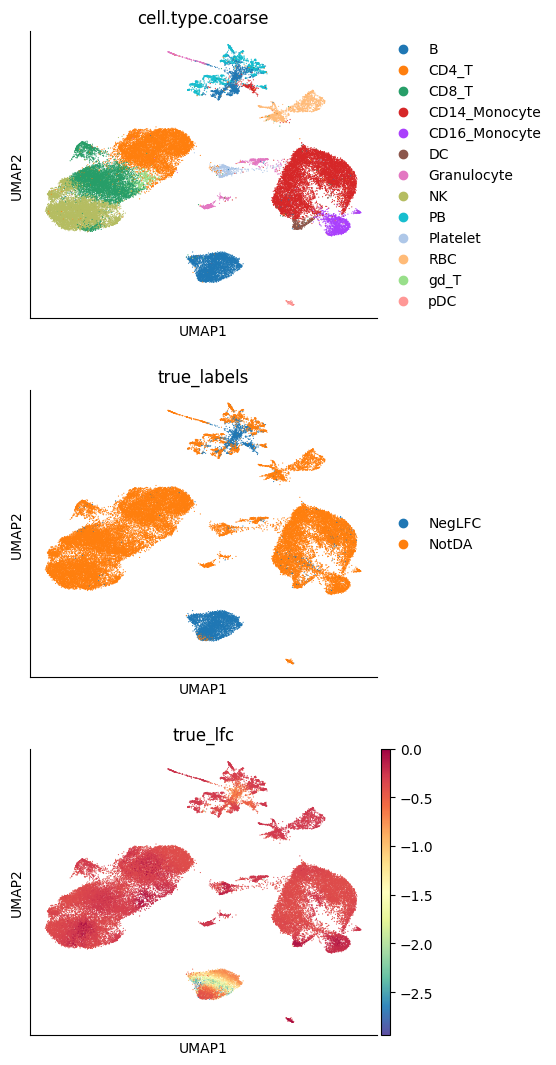

In [75]:
sc.pl.embedding(covid_ad_test,"umap",color = ["cell.type.coarse","true_labels","true_lfc"],ncols = 1)

## linear dm

In [9]:
linear_ad =  sc.read_h5ad("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/synthetic/linear/linear_anndata.h5ad")

In [10]:
linear_ad

AnnData object with n_obs × n_vars = 7500 × 500
    obs: 'cell_id', 'celltype'
    uns: 'X_name'
    obsm: 'PCA', 'UMAP', 'X_pca', 'X_umap'
    layers: 'logcounts'

In [11]:
dm_res = palantir.utils.run_diffusion_maps(linear_ad, n_components=10)

In [12]:
linear_copy = linear_ad.copy()

In [13]:
linear_copy.obsm["X_pca"] = linear_ad.obsm["DM_EigenVectors"]

In [14]:
linear_copy.obsm["X_pca"].shape

(7500, 10)

In [15]:
linear_copy.write("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/synthetic/linear/linear_anndata_dm_10.h5ad")

## branch dm

In [16]:
branch_ad =  sc.read_h5ad("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/synthetic/branch/branch_anndata.h5ad")

In [17]:
branch_ad

AnnData object with n_obs × n_vars = 7500 × 500
    obs: 'cell_id', 'celltype'
    uns: 'X_name', 'celltype_colors'
    obsm: 'PCA', 'UMAP', 'X_pca', 'X_umap'
    layers: 'logcounts'

In [18]:
dm_res = palantir.utils.run_diffusion_maps(branch_ad, n_components=10)

In [19]:
branch_copy = branch_ad.copy()

In [20]:
branch_copy.obsm["X_pca"] = branch_ad.obsm["DM_EigenVectors"]

In [21]:
branch_copy.obsm["X_pca"].shape

(7500, 10)

In [22]:
branch_copy.write("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/synthetic/branch/branch_anndata_dm_10.h5ad")

## cluster dm

In [3]:
cluster_ad =  sc.read_h5ad("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/synthetic/cluster/cluster_anndata.h5ad")

In [4]:
dm_res = palantir.utils.run_diffusion_maps(cluster_ad, n_components=10)

/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
cluster_copy = cluster_ad.copy()

In [6]:
cluster_copy.obsm["X_pca"] = cluster_ad.obsm["DM_EigenVectors"]

In [7]:
cluster_copy.obsm["X_pca"].shape

(2700, 10)

In [8]:
cluster_copy.write("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/synthetic/cluster/cluster_anndata_dm_10.h5ad")

## aging dataset dm

In [2]:
ad = sc.read_h5ad("/fh/fast/setty_m/user/ryang/differential_abundance/manuscript_preparation/aging_hematopoiesis_data_benchmarking.h5ad")

In [3]:
ad

AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype', 'midres_celltype_benchmarking', 'highres_celltype_benchmarking'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_benchmarking_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap'
    obsm: '

In [4]:
ad.obsm["DM_EigenVectors"].shape

(8090, 20)

In [5]:
dm_res = palantir.utils.run_diffusion_maps(ad, n_components=30)

/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
aging_copy = ad.copy()

In [7]:
aging_copy.obsm["X_pca"] = ad.obsm["DM_EigenVectors"]

In [24]:
aging_copy.obsm["X_pca"].shape


KeyboardInterrupt



In [9]:
aging_copy.write("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/real/aging/aging_dm.h5ad")

In [23]:
aging = sc.read_h5ad("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/real/aging/aging_dm.h5ad")

In [25]:
aging.obsm["X_pca"].shape

(8090, 30)

### pancrease

In [27]:
adata = sc.read_h5ad("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/real/pancreas/pancreas_anndata_revised.h5ad")

In [28]:
adata

AnnData object with n_obs × n_vars = 1597 × 28352
    obs: 'Sample.Characteristic.organism.', 'Sample.Characteristic.Ontology.Term.organism.', 'Sample.Characteristic.individual.', 'Sample.Characteristic.Ontology.Term.individual.', 'Sample.Characteristic.sex.', 'Sample.Characteristic.Ontology.Term.sex.', 'Sample.Characteristic.age.', 'Sample.Characteristic.Ontology.Term.age.', 'Sample.Characteristic.body.mass.index.', 'Sample.Characteristic.Ontology.Term.body.mass.index.', 'Sample.Characteristic.organism.status.', 'Sample.Characteristic.Ontology.Term.organism.status.', 'Sample.Characteristic.clinical.information.', 'Sample.Characteristic.Ontology.Term.clinical.information.', 'Sample.Characteristic.organism.part.', 'Sample.Characteristic.Ontology.Term.organism.part.', 'Sample.Characteristic.cell.type.', 'Sample.Characteristic.Ontology.Term.cell.type.', 'Sample.Characteristic.disease.', 'Sample.Characteristic.Ontology.Term.disease.', 'Sample.Characteristic.biosource.provider.', 'Sample.Ch

In [30]:
dm_res = palantir.utils.run_diffusion_maps(adata, n_components=30)

In [31]:
pancreas_copy = adata.copy()

In [32]:
pancreas_copy.obsm["X_pca"] = pancreas_copy.obsm["DM_EigenVectors"]

In [33]:
pancreas_copy.obsm["X_pca"].shape

(1597, 30)

In [34]:
pancreas_copy.write("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/real/pancreas/pancreas_dm.h5ad")